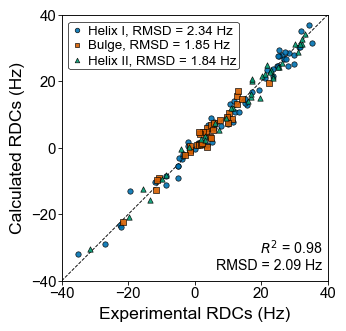

{'R': 0.991, 'R2': 0.981, 'RMSD_all': 2.089, 'N': 133, 'panel_size_in': (3.6, 3.2), 'dpi': 600}


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Input
# ===============================
path = "data/augmented_all.tsv"


x_vals, y_vals, resid_vals = [], [], []

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        parts = s.split()
        if len(parts) < 11:
            continue
        try:
            resid = int(parts[0])
            x = float(parts[8])   # Experimental RDCs
            y = float(parts[10])  # Calculated RDCs
        except Exception:
            continue

        if np.isfinite(x) and np.isfinite(y):
            resid_vals.append(resid)
            x_vals.append(x)
            y_vals.append(y)

x = np.array(x_vals, dtype=float)
y = np.array(y_vals, dtype=float)
resid_vals = np.array(resid_vals, dtype=int)
N = x.size

# ===============================
# Define residue regions & masks
# ===============================
mask_helix1 = ((resid_vals >= 1) & (resid_vals <= 6)) | ((resid_vals >= 24) & (resid_vals <= 29))
mask_bulge  = (resid_vals >= 7) & (resid_vals <= 9)
mask_helix2 = ((resid_vals >= 10) & (resid_vals <= 13)) | ((resid_vals >= 20) & (resid_vals <= 23))
mask_loop   = (resid_vals >= 14) & (resid_vals <= 19)

def region_rmsd(mask):
    if np.sum(mask) == 0:
        return np.nan
    return float(np.sqrt(np.mean((y[mask] - x[mask])**2)))

rmsd_helix1 = region_rmsd(mask_helix1)
rmsd_bulge  = region_rmsd(mask_bulge)
rmsd_helix2 = region_rmsd(mask_helix2)
rmsd_loop   = region_rmsd(mask_loop)

# --- Global metrics ---
r = float(np.corrcoef(x, y)[0, 1]) if N >= 2 else np.nan
r2 = r**2 if N >= 2 else np.nan
rmsd_all = float(np.sqrt(np.mean((y - x) ** 2))) if N >= 1 else np.nan

# ===============================
# Style: color + shape
# ===============================
region_style = {
    "Helix I":  {"mask": mask_helix1, "color": "#0072B2", "marker": "o", "rmsd": rmsd_helix1},
    "Bulge":    {"mask": mask_bulge,  "color": "#D55E00", "marker": "s", "rmsd": rmsd_bulge},
    "Helix II": {"mask": mask_helix2, "color": "#009E73", "marker": "^", "rmsd": rmsd_helix2},
    "Loop":     {"mask": mask_loop,   "color": "#CC79A7", "marker": "D", "rmsd": rmsd_loop},
}

# ===============================
# Final panel size for the multi-panel figure
# ===============================
PANEL_W = 3.6   # in
PANEL_H = 3.2   # slightly taller to accommodate legend
EXPORT_DPI = 600

# final printed font sizes
BASE_FONT    = 5.6*2
AXIS_LABEL   = 6.3*2
TICK_LABEL   = 5.4*2  
ANNOT_FONT   = 5.1*2
LEGEND_FONT  = 4.8*2
PANEL_TAG    = 6.8*2

# line widths
AXES_LW      = 0.65
TICK_W       = 0.60
IDENTITY_LW  = 0.65
EDGE_LW      = 0.50
LEGEND_LW    = 0.50

MARKER_SIZE = 15

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": BASE_FONT,
    "axes.linewidth": AXES_LW,
    "axes.labelsize": AXIS_LABEL,
    "xtick.labelsize": TICK_LABEL,
    "ytick.labelsize": TICK_LABEL,
    "xtick.major.size": 2.8,
    "ytick.major.size": 2.8,
    "xtick.major.width": TICK_W,
    "ytick.major.width": TICK_W,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots(figsize=(PANEL_W, PANEL_H), constrained_layout=True)

# ===============================
# Scatter points + collect legend
# ===============================
handles = []
labels = []

for region_name, st in region_style.items():
    mask = st["mask"]
    if not np.any(mask):
        continue

    h = ax.scatter(
        x[mask], y[mask],
        s=MARKER_SIZE,
        alpha=0.90,
        linewidth=EDGE_LW,
        edgecolor="black",
        color=st["color"],
        marker=st["marker"],
        zorder=3,
    )
    handles.append(h)
    labels.append(f"{region_name}, RMSD = {st['rmsd']:.2f} Hz")

# ===============================
# Identity line
# ===============================
lo, hi = -40, 40
xx = np.linspace(lo, hi, 400)
ax.plot(xx, xx, linestyle="--", linewidth=IDENTITY_LW, color="black", zorder=2)

# ===============================
# Axes
# ===============================
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ticks = list(range(lo, hi + 1, 20))
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("Experimental RDCs (Hz)")
ax.set_ylabel("Calculated RDCs (Hz)")
ax.tick_params(direction="out", length=2.8, width=TICK_W, pad=1.2)

for spine in ax.spines.values():
    spine.set_linewidth(AXES_LW)

# ===============================
# Compact metrics annotation
# ===============================
metrics_text = (
    f"$R^2$ = {r2:.2f}\n"
    f"RMSD = {rmsd_all:.2f} Hz"
)

ax.text(
    0.98, 0.03, metrics_text,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=ANNOT_FONT,
    bbox=dict(boxstyle="round,pad=0.14", facecolor="white", edgecolor="none", alpha=0.90),
    zorder=4,
)

# ===============================
# Full legend kept in panel
# ===============================
if handles:
    leg = ax.legend(
        handles, labels,
        loc="upper left",
        frameon=True,
        fontsize=LEGEND_FONT,
        handlelength=0.9,
        handletextpad=0.35,
        borderpad=0.20,
        labelspacing=0.20,
        markerscale=0.85,
        scatterpoints=1,
    )
    frame = leg.get_frame()
    frame.set_edgecolor("black")
    frame.set_linewidth(LEGEND_LW)
    frame.set_facecolor("white")
    frame.set_alpha(0.95)

# ===============================
# Panel label
# # ===============================
# ax.text(
#     -0.18, 1.05, "A",
#     transform=ax.transAxes,
#     ha="left", va="bottom",
#     fontsize=PANEL_TAG,
#     fontweight="bold"
# )

# ===============================
# Save
# ===============================
out_base = "figure_2_T-REMD_330_rdc_correlation"

fig.savefig(f"{out_base}.png", dpi=EXPORT_DPI)
plt.show()

print({
    "R": round(r, 3),
    "R2": round(r2, 3),
    "RMSD_all": round(rmsd_all, 3),
    "N": int(N),
    "panel_size_in": (PANEL_W, PANEL_H),
    "dpi": EXPORT_DPI,
})